In [1]:
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import (
    train_test_split
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier


import joblib

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

plt.style.use("ggplot")

print("Libraries imported successfully.")

c:\Users\shiva\Desktop\SentinelAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


In [2]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources ready.")

NLTK resources ready.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:

SEED = 42

ROOT_DIR = Path.cwd().parents[1]
DATA_PATH = Path.cwd() / "combined_dataset.csv"
MODEL_DIR = ROOT_DIR / "models" / "sms"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/Users/shiva/Desktop/SentinelAI/datasets/sms/combined_dataset.csv')

In [4]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df.head()

,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


In [5]:
df = df.iloc[:, :2]

df.columns = [
    "label",
    "message"
]

df.head()

,label,message
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


In [6]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...


In [7]:
required_columns = ["label", "message"]

assert all(col in df.columns for col in required_columns), "Missing required columns."

assert not df.empty, "Dataset is empty."

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10961 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    10961 non-null  int64
 1   message  10961 non-null  str  
dtypes: int64(1), str(1)
memory usage: 5.7 MB


In [8]:
display(df.describe(include="all"))

,label,message
count,10961.000000,10961
unique,NaN,10286
top,NaN,"Sorry, I'll call later"
freq,NaN,30
mean,0.219506,NaN
std,0.413931,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,0.000000,NaN


In [9]:
overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Messages",
        "Unique Messages",
        "Spam Messages",
        "Legitimate Messages"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["message"].duplicated().sum(),
        df["message"].nunique(),
        (df["label"] == 1).sum(),
        (df["label"] == 0).sum()
    ]
})

overview

,Metric,Value
0,Rows,10961
1,Columns,2
2,Missing Values,0
3,Duplicate Rows,674
4,Duplicate Messages,675
5,Unique Messages,10286
6,Spam Messages,2406
7,Legitimate Messages,8555


In [10]:
df["char_count"] = df["message"].str.len()

df["word_count"] = df["message"].str.split().str.len()

df["sentence_count"] = (
    df["message"]
    .str.count(r"[.!?]")
    .fillna(0)
    .astype(int)
    + 1
)

df[["char_count", "word_count", "sentence_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,10961.0,530.494663,1139.165012,1.0,55.0,140.0,491.0,31851.0
word_count,10961.0,116.172612,254.166677,0.0,11.0,26.0,111.0,8861.0
sentence_count,10961.0,8.339568,23.088971,1.0,2.0,4.0,8.0,1262.0


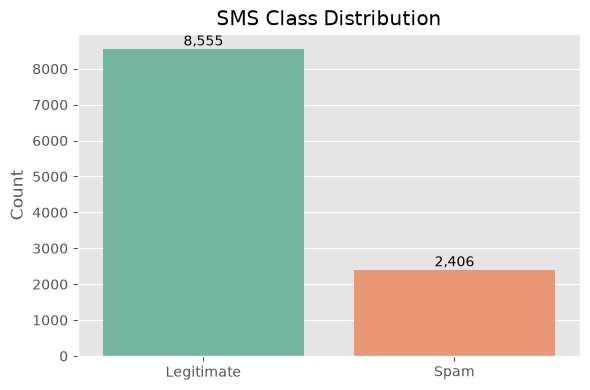

In [11]:
class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Legitimate", "Spam"],
    y=class_counts.values,
    hue=["Legitimate", "Spam"],
    palette="Set2",
    legend=False
)

plt.title("SMS Class Distribution")
plt.xlabel("")
plt.ylabel("Count")

for i, value in enumerate(class_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [12]:
class_percent = (
    df["label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_percent.rename(
    index={
        0: "Legitimate",
        1: "Spam"
    }
).to_frame("Percentage")

,Percentage
label,
Legitimate,78.049448
Spam,21.950552


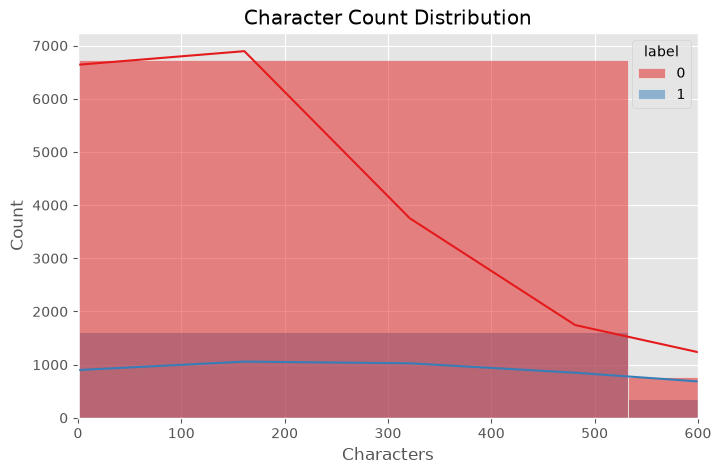

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="char_count",
    hue="label",
    bins=60,
    kde=True,
    palette="Set1"
)

plt.xlim(0, 600)
plt.title("Character Count Distribution")
plt.xlabel("Characters")

plt.show()

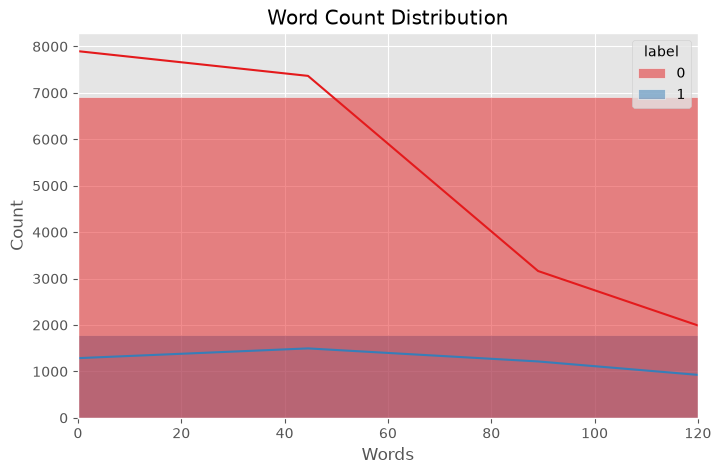

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=60,
    kde=True,
    palette="Set1"
)

plt.xlim(0, 120)
plt.title("Word Count Distribution")
plt.xlabel("Words")

plt.show()

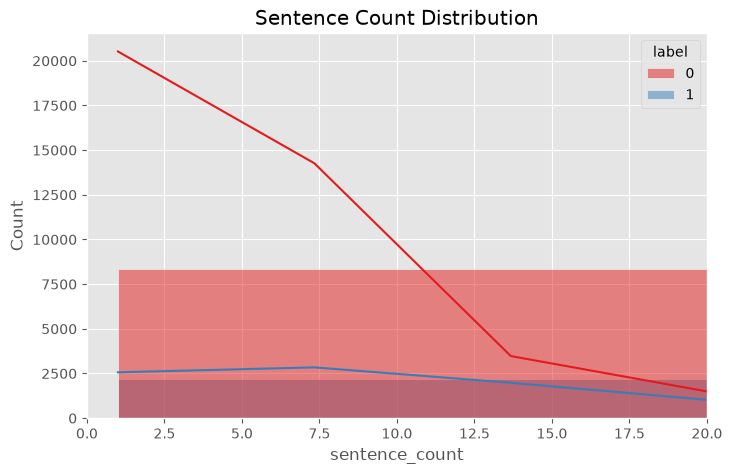

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sentence_count",
    hue="label",
    bins=40,
    kde=True,
    palette="Set1"
)

plt.xlim(0, 20)
plt.title("Sentence Count Distribution")

plt.show()

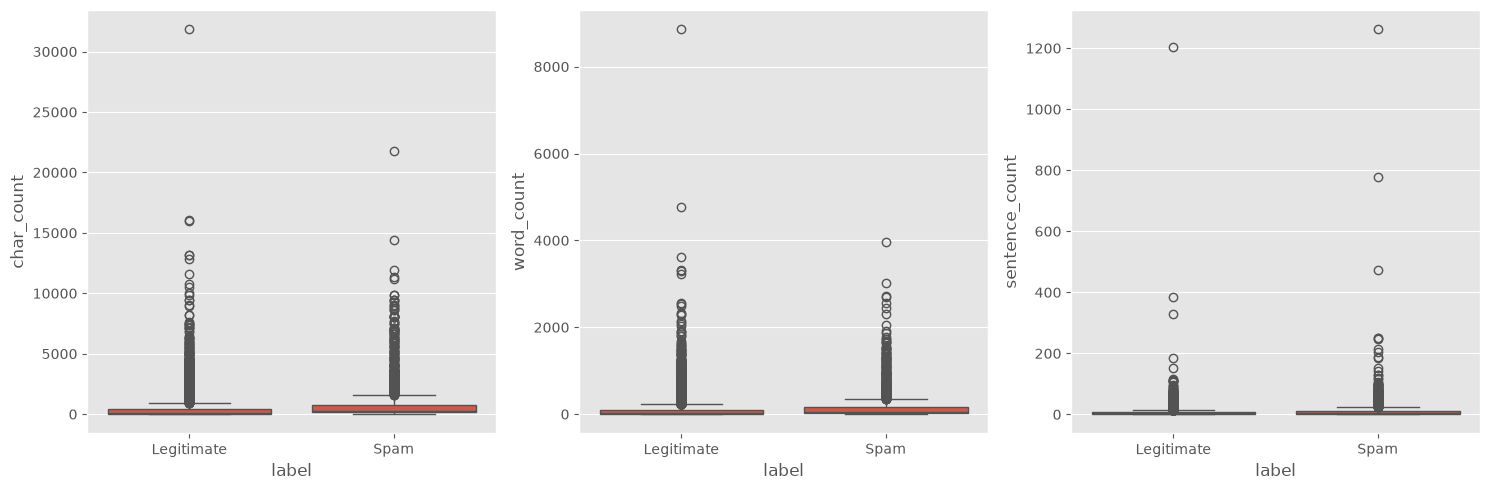

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(
    data=df,
    x="label",
    y="char_count",
    ax=axes[0]
)

sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    ax=axes[1]
)

sns.boxplot(
    data=df,
    x="label",
    y="sentence_count",
    ax=axes[2]
)

axes[0].set_xticklabels(["Legitimate", "Spam"])
axes[1].set_xticklabels(["Legitimate", "Spam"])
axes[2].set_xticklabels(["Legitimate", "Spam"])

plt.tight_layout()
plt.show()

In [17]:
df.groupby("label")[["char_count", "word_count", "sentence_count"]].agg(
    ["mean", "median", "std", "min", "max"]
)

char_count                                 word_count         \
             mean median          std min    max        mean median   
label                                                                 
0      454.463939  104.0   995.982199   2  31851  105.250263   22.0   
1      800.836658  220.5  1513.907953   1  21740  155.009144   44.0   

                            sentence_count                              
              std min   max           mean median        std min   max  
label                                                                   
0      241.524663   1  8861       7.021274    4.0  17.017376   1  1205  
1      291.518170   0  3961      13.027016    6.0  37.030567   1  1262

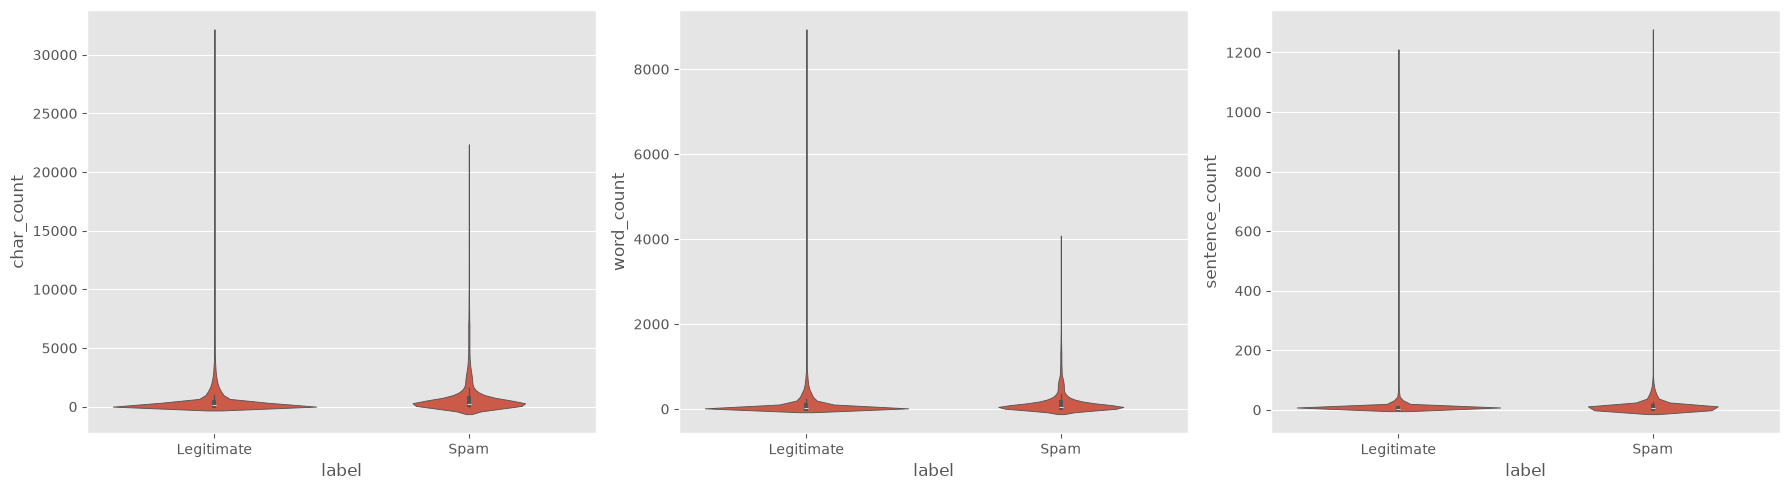

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=df, x="label", y="char_count", ax=axes[0])
sns.violinplot(data=df, x="label", y="word_count", ax=axes[1])
sns.violinplot(data=df, x="label", y="sentence_count", ax=axes[2])

for ax in axes:
    ax.set_xticklabels(["Legitimate", "Spam"])

plt.tight_layout()
plt.show()

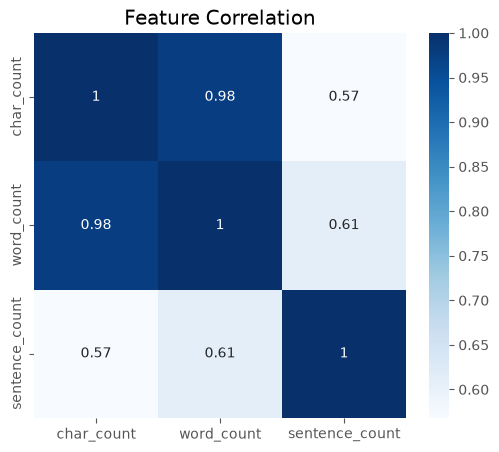

In [19]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    df[["char_count", "word_count", "sentence_count"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")
plt.show()

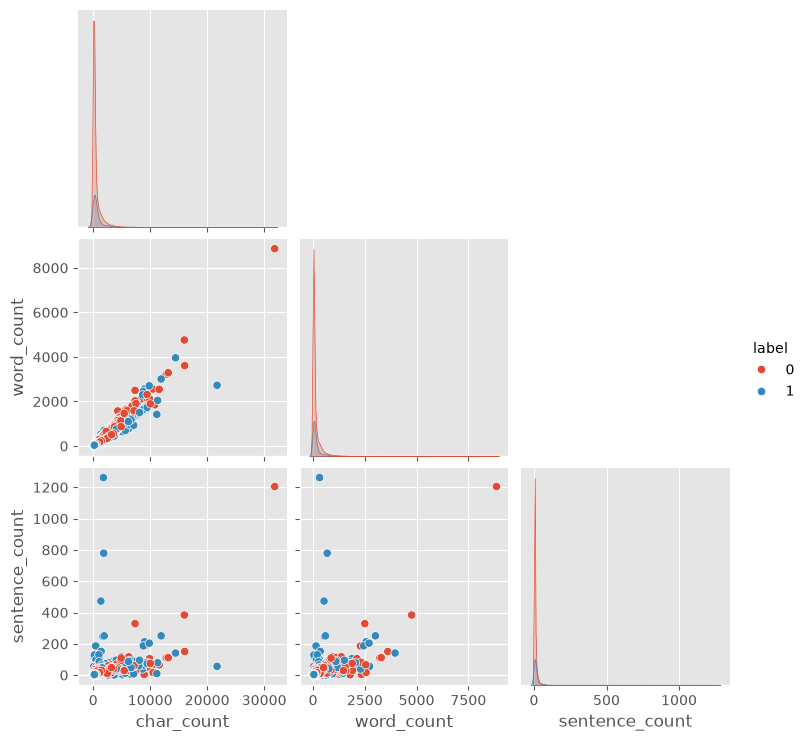

In [20]:
sns.pairplot(
    df,
    vars=["char_count", "word_count", "sentence_count"],
    hue="label",
    corner=True
)

plt.show()

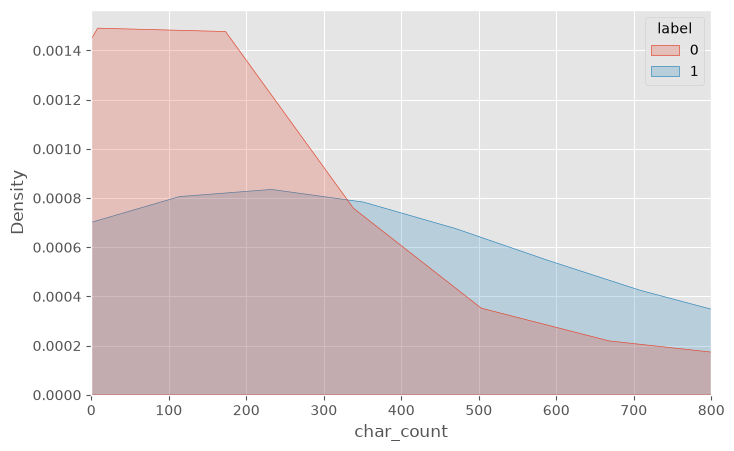

In [21]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="char_count",
    hue="label",
    fill=True,
    common_norm=False
)

plt.xlim(0,800)

plt.show()

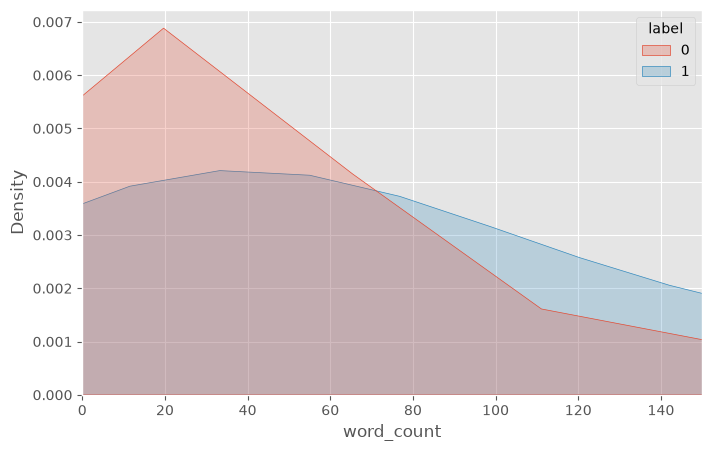

In [22]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="word_count",
    hue="label",
    fill=True,
    common_norm=False
)

plt.xlim(0,150)

plt.show()

In [23]:
df.nlargest(
    10,
    "char_count"
)[["label", "char_count", "message"]]

,label,char_count,message
1058,0,31851,"fw : "" red , white and blue out "" - - - - - or..."
2097,1,21740,online pharxmacy 80 % off all meds disscount p...
4396,0,16052,the expatriate zone - issue # 1 2 / 14 / 00 th...
3669,0,15990,fw : thought this was important bammelyoungfam...
4901,1,14451,"we ' ve got your info by internet , hope to co..."
5012,0,13169,"re : coastal oil & gas corporation melissa , d..."
3044,0,13161,"re : coastal oil & gas corporation daren , fyi..."
937,0,12821,"re : coastal oil & gas corporation daren , fyi..."
3623,1,11923,free profiles you choose derm htmlheadtitlelt ...
4358,0,11576,re : sitara release ( re : changes in global d...


In [24]:
url_pattern = r"(https?://\S+|www\.\S+)"

df["url_count"] = df["message"].str.count(url_pattern)

df.groupby("label")["url_count"].sum().rename({
    0: "Legitimate",
    1: "Spam"
}).to_frame("URLs")

,URLs
label,
Legitimate,21
Spam,117


In [25]:
phone_pattern = r"\b\d{10,15}\b"

df["phone_count"] = df["message"].str.count(phone_pattern)

df.groupby("label")["phone_count"].sum().rename({
    0: "Legitimate",
    1: "Spam"
}).to_frame("Phone Numbers")

,Phone Numbers
label,
Legitimate,17
Spam,446


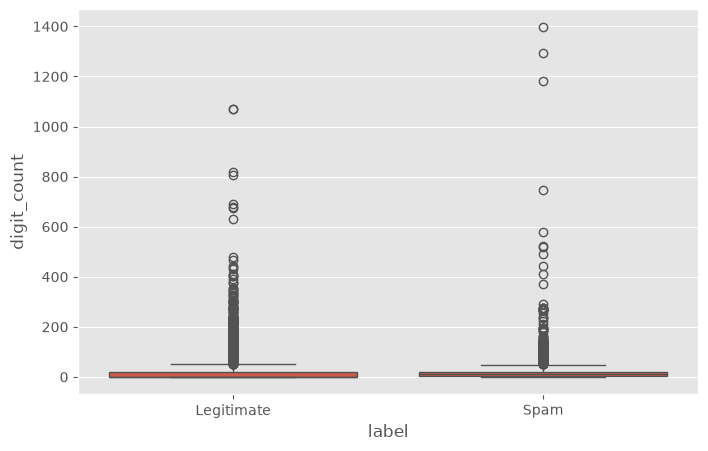

In [26]:
df["digit_count"] = df["message"].str.count(r"\d")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="digit_count"
)

plt.xticks([0,1],["Legitimate","Spam"])

plt.show()

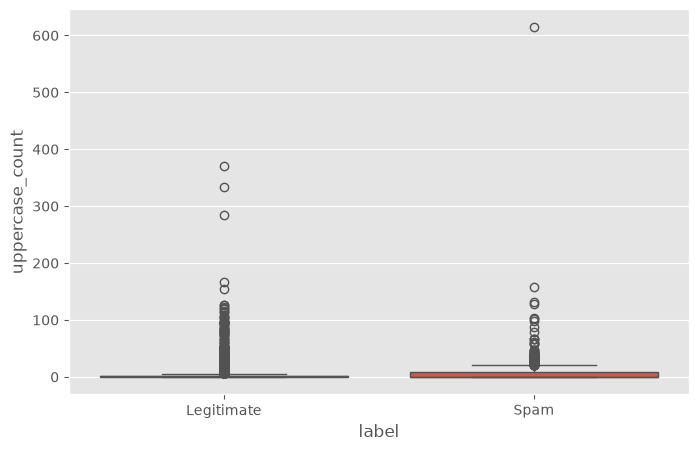

In [27]:
df["uppercase_count"] = df["message"].str.count(r"[A-Z]")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="uppercase_count"
)

plt.xticks([0,1],["Legitimate","Spam"])

plt.show()

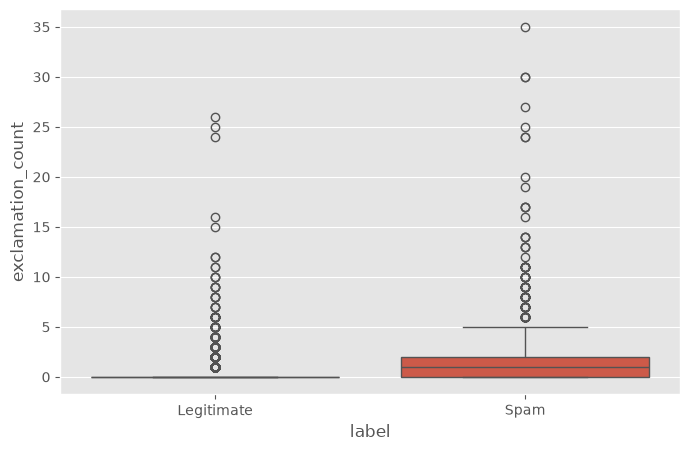

In [28]:
df["exclamation_count"] = df["message"].str.count("!")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="exclamation_count"
)

plt.xticks([0,1],["Legitimate","Spam"])

plt.show()

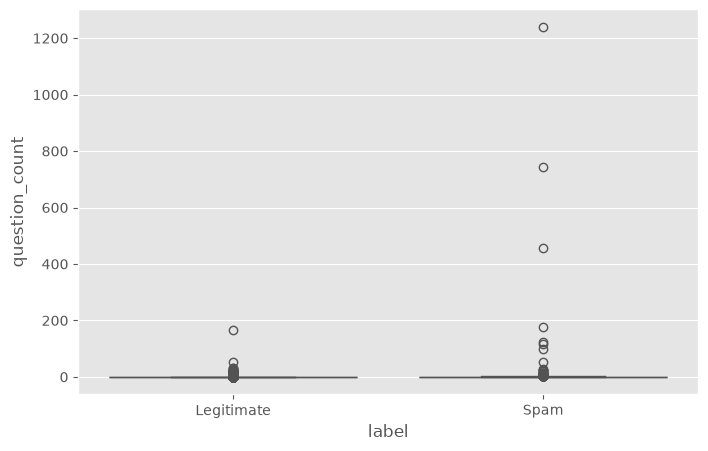

In [29]:
df["question_count"] = df["message"].str.count(r"\?")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="question_count"
)

plt.xticks([0,1],["Legitimate","Spam"])

plt.show()

In [30]:
df["currency_count"] = df["message"].str.count(r"[$₹£€]")

df.groupby("label")["currency_count"].sum().rename({
    0:"Legitimate",
    1:"Spam"
}).to_frame("Currency Symbols")

,Currency Symbols
label,
Legitimate,1254
Spam,1699


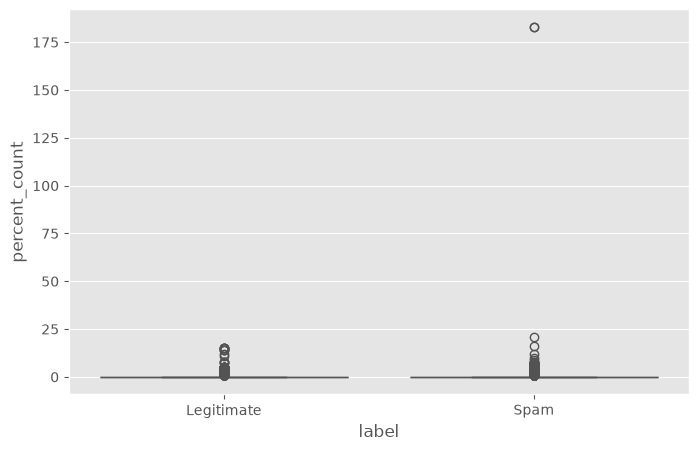

In [31]:
df["percent_count"] = df["message"].str.count("%")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="percent_count"
)

plt.xticks([0,1],["Legitimate","Spam"])

plt.show()

In [32]:
df[df["label"] == 1] \
    .nlargest(20, "char_count") \
    [["char_count", "message"]]

,char_count,message
2097,21740,online pharxmacy 80 % off all meds disscount p...
4901,14451,"we ' ve got your info by internet , hope to co..."
3623,11923,free profiles you choose derm htmlheadtitlelt ...
5150,11309,"( otcbb : itst ) up 38 % , uregent news alert ..."
3169,11160,54 - cy . . . adrian hideout or ( der the best...
328,9896,breaking news : abdv goes energy epgqlahhkqqlt...
3841,9833,ad - when he said he could make me famous if i...
697,9485,impact equity report mineral exploration stock...
2712,9482,picks from analyst with high - level precision...
4822,9475,"hot stock mover advisory yap internationa | , ..."


In [33]:
df[df["label"] == 0] \
    .nlargest(20, "char_count") \
    [["char_count", "message"]]

,char_count,message
1058,31851,"fw : "" red , white and blue out "" - - - - - or..."
4396,16052,the expatriate zone - issue # 1 2 / 14 / 00 th...
3669,15990,fw : thought this was important bammelyoungfam...
5012,13169,"re : coastal oil & gas corporation melissa , d..."
3044,13161,"re : coastal oil & gas corporation daren , fyi..."
937,12821,"re : coastal oil & gas corporation daren , fyi..."
4358,11576,re : sitara release ( re : changes in global d...
2154,10803,organizational changes we are making a number ...
2868,10506,hpl optimization please make sure your staff r...
5228,10021,bpa rate case - seasonal rates - - - - - - - -...


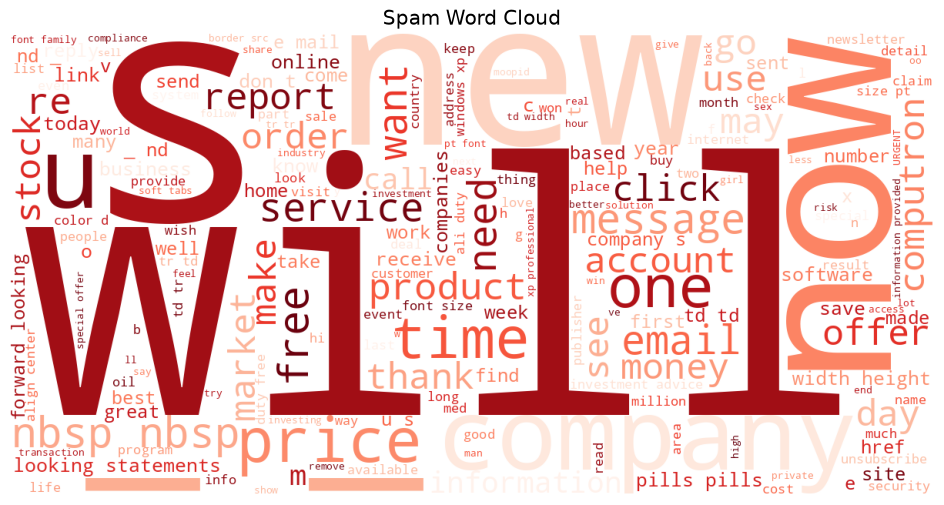

In [34]:
spam_text = " ".join(df.loc[df["label"] == 1, "message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"
).generate(spam_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

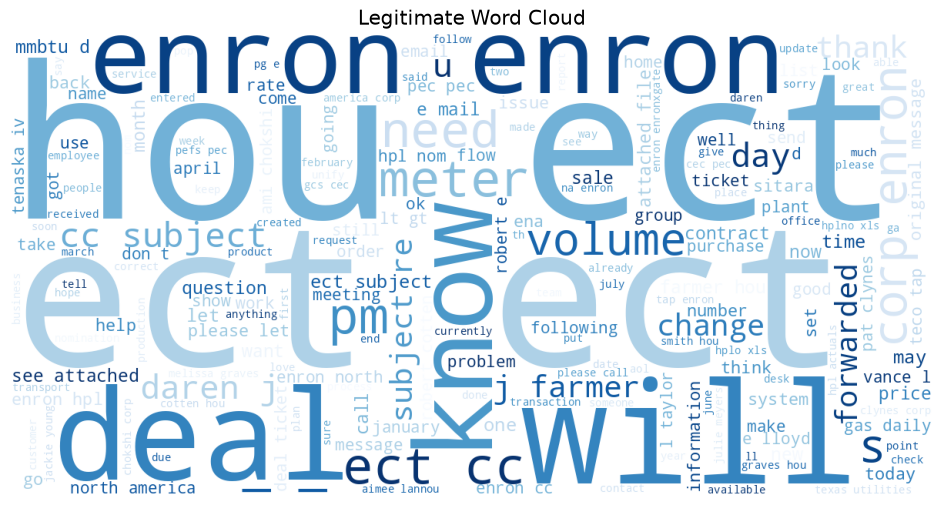

In [35]:
ham_text = " ".join(df.loc[df["label"] == 0, "message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues"
).generate(ham_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Legitimate Word Cloud")
plt.show()

In [36]:

vectorizer = CountVectorizer(stop_words="english", max_features=30)

X = vectorizer.fit_transform(df.loc[df["label"] == 1, "message"])

counts = np.asarray(X.sum(axis=0)).ravel()

spam_words = (
    pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": counts
    })
    .sort_values("count", ascending=False)
)

spam_words

,word,count
5,com,1049
12,http,1004
6,company,731
29,www,686
0,00,600
10,free,565
13,information,530
19,new,518
9,font,515
26,td,504


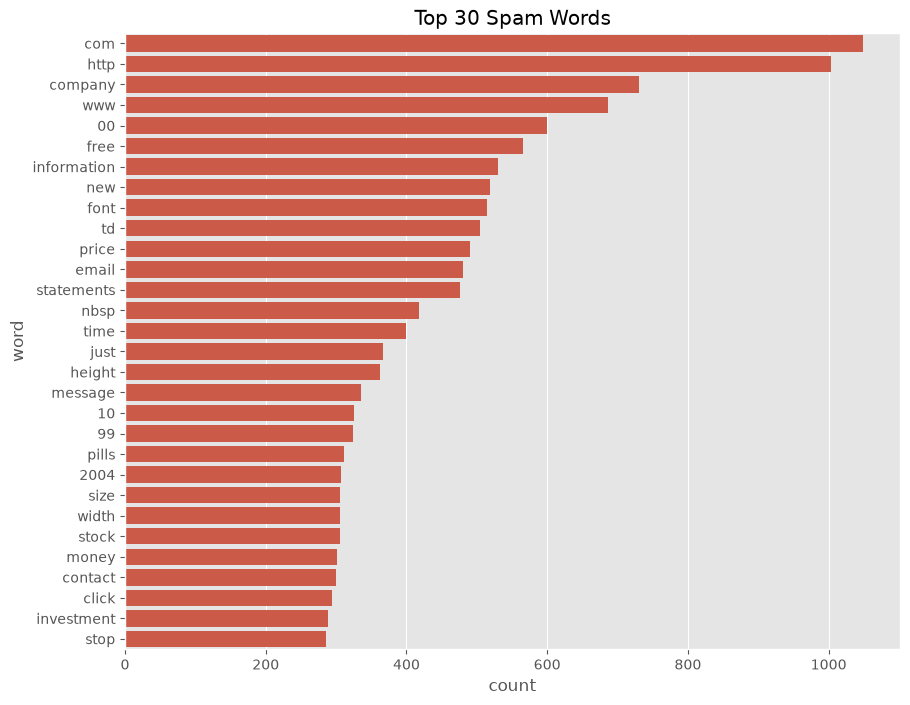

In [37]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=spam_words,
    x="count",
    y="word"
)

plt.title("Top 30 Spam Words")
plt.show()

In [38]:
vectorizer = CountVectorizer(stop_words="english", max_features=30)

X = vectorizer.fit_transform(df.loc[df["label"] == 0, "message"])

counts = np.asarray(X.sum(axis=0)).ravel()

ham_words = (
    pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": counts
    })
    .sort_values("count", ascending=False)
)

ham_words

,word,count
14,ect,13897
19,hou,7281
15,enron,6555
7,2000,4309
18,gas,2875
13,deal,2798
10,com,2780
28,subject,2738
23,meter,2459
9,cc,2359


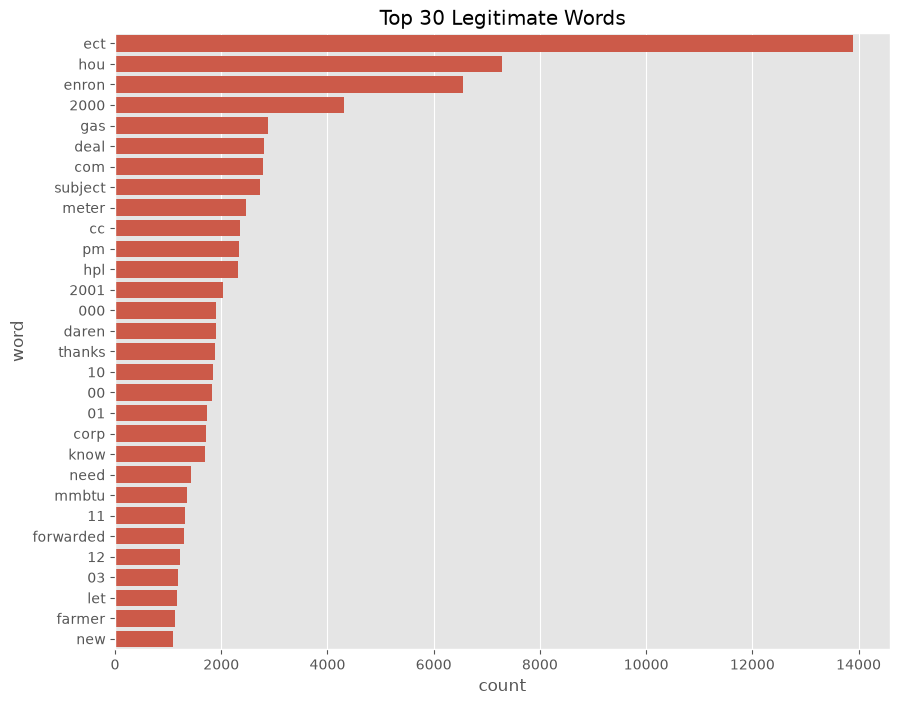

In [39]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=ham_words,
    x="count",
    y="word"
)

plt.title("Top 30 Legitimate Words")
plt.show()

In [40]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=30
)

X = vectorizer.fit_transform(df["message"])

counts = np.asarray(X.sum(axis=0)).ravel()

bigrams = (
    pd.DataFrame({
        "bigram": vectorizer.get_feature_names_out(),
        "count": counts
    })
    .sort_values("count", ascending=False)
)

bigrams

,bigram,count
18,hou ect,7226
10,ect ect,6339
14,enron enron,1434
9,ect cc,1391
7,corp enron,1214
6,cc subject,1094
20,let know,1047
8,daren farmer,933
13,enron com,831
11,ect subject,730


In [41]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(3, 3),
    max_features=30
)

X = vectorizer.fit_transform(df["message"])

counts = np.asarray(X.sum(axis=0)).ravel()

trigrams = (
    pd.DataFrame({
        "trigram": vectorizer.get_feature_names_out(),
        "count": counts
    })
    .sort_values("count", ascending=False)
)

trigrams

,trigram,count
18,hou ect ect,6271
9,ect ect cc,1383
5,corp enron enron,907
10,ect ect subject,715
8,ect cc subject,599
7,daren farmer hou,563
15,farmer hou ect,563
12,enron enron cc,304
14,enron north america,283
23,north america corp,255


In [42]:
duplicates = df[df.duplicated(subset="message", keep=False)]

duplicates["label"].value_counts().rename({
    0: "Legitimate",
    1: "Spam"
})

label
Legitimate    949
Spam          243
Name: count, dtype: int64

In [43]:
df[["char_count", "word_count"]].quantile(
    [0.5, 0.75, 0.90, 0.95, 0.99]
)

,char_count,word_count
0.50,140.0,26.0
0.75,491.0,111.0
0.90,1407.0,323.0
0.95,2349.0,527.0
0.99,5576.8,1149.2


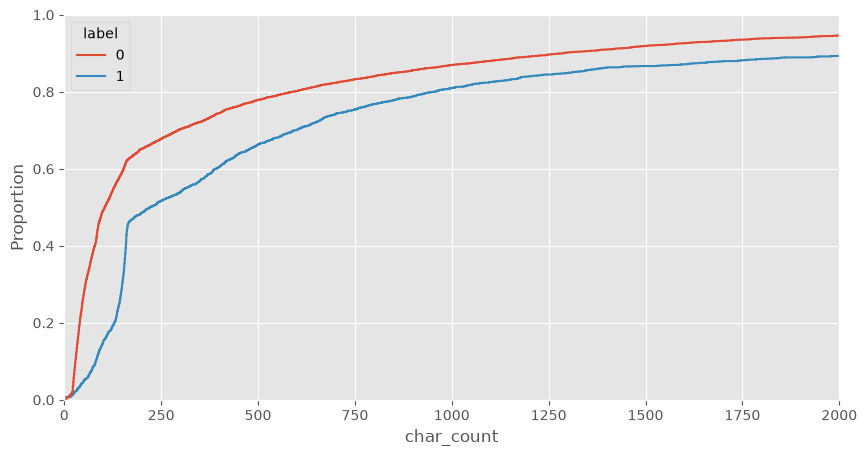

In [44]:
plt.figure(figsize=(10,5))

sns.ecdfplot(
    data=df,
    x="char_count",
    hue="label"
)

plt.xlim(0,2000)

plt.show()

In [45]:
domains = (
    df["message"]
    .str.extractall(r"(?:https?://)?(?:www\.)?([A-Za-z0-9.-]+\.[A-Za-z]{2,})")[0]
    .value_counts()
    .head(20)
)

domains

0
I.ll                       19
Amazon.com                 14
getzed.co.uk               10
i.ll                        9
fullonsms.com               8
SMS.ac                      6
bit.ly                      6
Ldew.com                    5
comuk.net                   5
urawinner.com               5
gmail.com                   5
ringtones.co.uk             4
message..Its                4
BLOOD.Send                  4
govt.instituitions          4
Jobstreet.com               4
calls..messages..missed     3
4-tc.biz                    3
100percent-real.com         3
sleeping..and               3
Name: count, dtype: int64

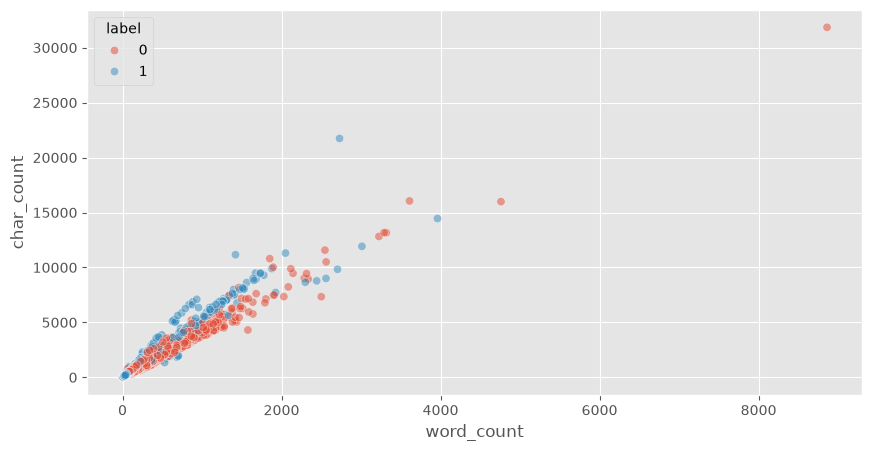

In [46]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="word_count",
    y="char_count",
    hue="label",
    alpha=0.5
)

plt.show()

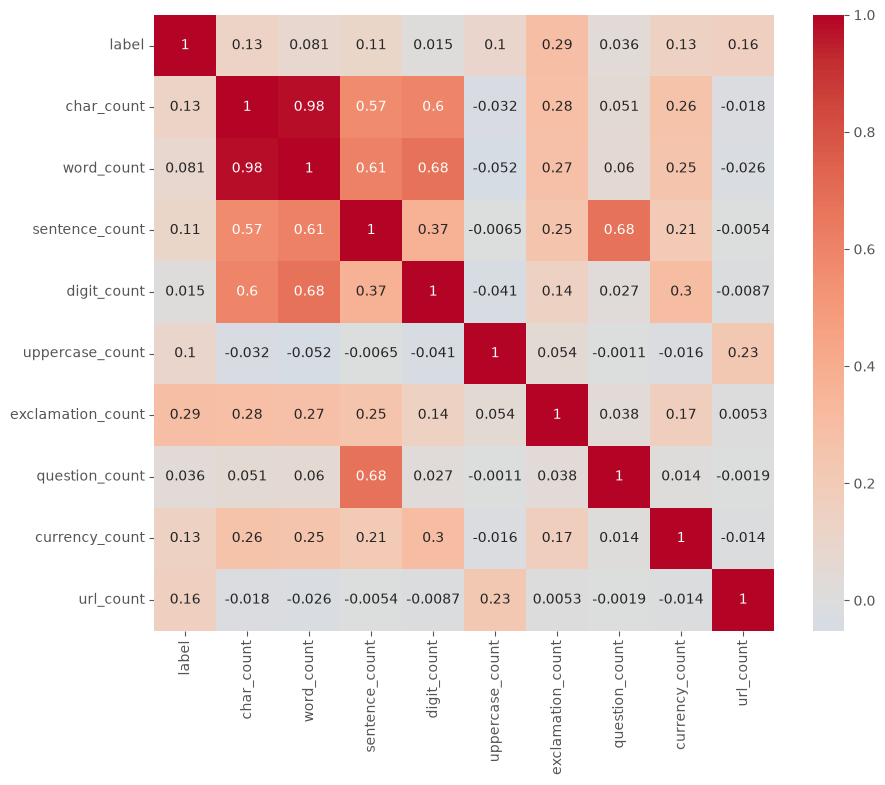

In [47]:
numeric_cols = [
    "label",
    "char_count",
    "word_count",
    "sentence_count",
    "digit_count",
    "uppercase_count",
    "exclamation_count",
    "question_count",
    "currency_count",
    "url_count"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

In [48]:
df["char_count"].value_counts().head(20)

char_count
22    124
32    102
24    102
23    101
26     90
38     86
28     85
33     84
84     83
27     83
34     83
29     82
40     82
25     82
37     81
31     79
36     78
30     78
45     76
35     74
Name: count, dtype: int64

In [49]:
def clean_for_eda(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [50]:
df["eda_text"] = df["message"].apply(clean_for_eda)

In [51]:
before = len(df)

df = df.drop_duplicates(subset="message").reset_index(drop=True)

after = len(df)

print(f"Removed {before - after} duplicate messages")
print(f"Remaining: {after}")

Removed 675 duplicate messages
Remaining: 10286


In [52]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [53]:
def clean_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text,
    )

    text = re.sub(r"\+?\d[\d\s()-]{7,}\d", " ", text)

    text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"_", " ", text)

    text = re.sub(r"\d+", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [54]:
def preprocess_text(text):
    text = clean_text(text)

    tokens = nltk.word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha()
        and token not in stop_words
        and len(token) > 1
    ]

    return " ".join(tokens)

In [55]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,Congratulations! You've been selected for a lu...,congratulation selected luxury vacation getawa...
1,URGENT: Your account has been compromised. Cli...,urgent account compromised click reset passwor...
2,You've won a free iPhone! Claim your prize by ...,free iphone claim prize clicking link
3,Act now and receive a 50% discount on all purc...,act receive discount purchase limited time offer
4,Important notice: Your subscription will expir...,important notice subscription expire soon rene...


In [56]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shiva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

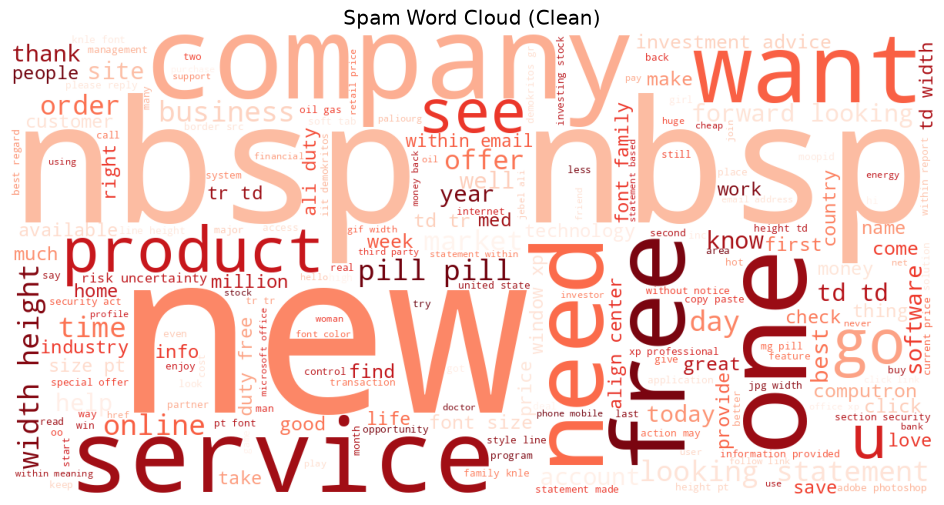

In [57]:
spam_text = " ".join(df.loc[df["label"] == 1, "clean_message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"
).generate(spam_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam Word Cloud (Clean)")
plt.show()

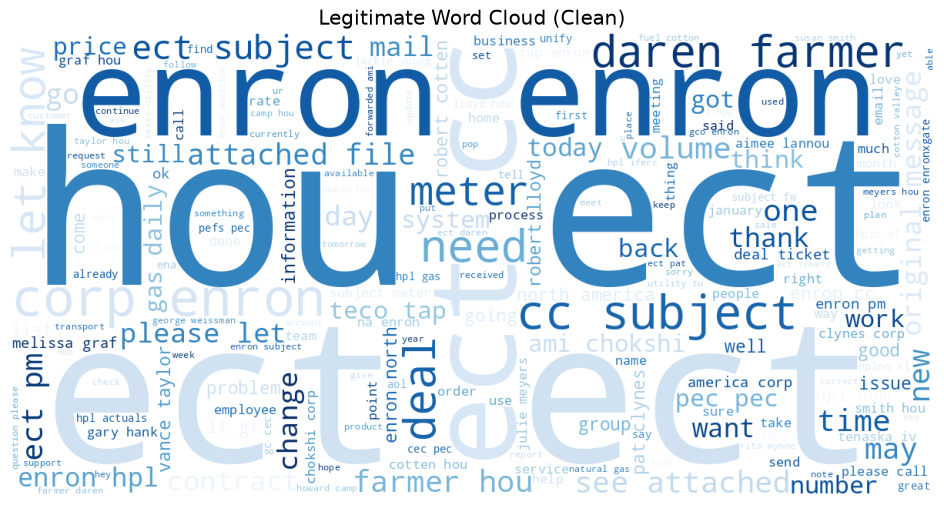

In [58]:
ham_text = " ".join(df.loc[df["label"] == 0, "clean_message"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues"
).generate(ham_text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Legitimate Word Cloud (Clean)")
plt.show()

In [59]:
vectorizer = CountVectorizer(max_features=30)

X = vectorizer.fit_transform(
    df.loc[df["label"] == 1, "clean_message"]
)

spam_words = (
    pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": np.asarray(X.sum(axis=0)).ravel()
    })
    .sort_values("count", ascending=False)
)

spam_words

,word,count
1,com,1005
8,http,980
2,company,922
19,price,729
6,get,604
29,www,586
5,free,535
18,please,532
9,information,527
4,font,515


In [60]:
vectorizer = CountVectorizer(max_features=30)

X = vectorizer.fit_transform(
    df.loc[df["label"] == 0, "clean_message"]
)

ham_words = (
    pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": np.asarray(X.sum(axis=0)).ravel()
    })
    .sort_values("count", ascending=False)
)

ham_words

,word,count
9,ect,13578
15,hou,7109
10,enron,6332
8,deal,3402
24,please,2714
13,gas,2708
3,com,2693
20,meter,2660
27,subject,2634
1,cc,2273


In [61]:
X = df["clean_message"]
y = df["label"]

In [62]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(7200,)
(1543,)
(1543,)


In [63]:
count_vectorizer = CountVectorizer(
    lowercase=False,
    max_features=10000,
    ngram_range=(1,2)
)

X_train_count = count_vectorizer.fit_transform(X_train)

X_val_count = count_vectorizer.transform(X_val)

X_test_count = count_vectorizer.transform(X_test)

print(X_train_count.shape)

(7200, 10000)


In [64]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    max_features=10000,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_val_tfidf = tfidf_vectorizer.transform(X_val)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(7200, 10000)


In [65]:
comparison = pd.DataFrame({
    "Vectorizer": [
        "Count",
        "TF-IDF"
    ],
    "Vocabulary Size": [
        len(count_vectorizer.vocabulary_),
        len(tfidf_vectorizer.vocabulary_)
    ],
    "Training Shape": [
        X_train_count.shape,
        X_train_tfidf.shape
    ]
})

comparison

,Vectorizer,Vocabulary Size,Training Shape
0,Count,10000,"(7200, 10000)"
1,TF-IDF,10000,"(7200, 10000)"


In [66]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

val_pred = nb_model.predict(X_val_tfidf)

print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1202
           1       0.93      0.82      0.87       341

    accuracy                           0.94      1543
   macro avg       0.94      0.90      0.92      1543
weighted avg       0.94      0.94      0.94      1543



In [67]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

lr_model.fit(X_train_tfidf, y_train)

val_pred = lr_model.predict(X_val_tfidf)

print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      1202
           1       0.97      0.76      0.85       341

    accuracy                           0.94      1543
   macro avg       0.95      0.88      0.91      1543
weighted avg       0.94      0.94      0.94      1543



In [68]:
svm = LinearSVC(random_state=SEED)

svm_model = CalibratedClassifierCV(svm)

svm_model.fit(X_train_tfidf, y_train)

val_pred = svm_model.predict(X_val_tfidf)

print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1202
           1       0.94      0.87      0.90       341

    accuracy                           0.96      1543
   macro avg       0.95      0.93      0.94      1543
weighted avg       0.96      0.96      0.96      1543



In [69]:
lgbm_model = LGBMClassifier(
    random_state=SEED,
    n_estimators=300,
    learning_rate=0.05
)

lgbm_model.fit(X_train_tfidf, y_train)

val_pred = lgbm_model.predict(X_val_tfidf)

print(classification_report(y_val, val_pred))

[LightGBM] [Info] Number of positive: 1591, number of negative: 5609
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 68757
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 2965
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220972 -> initscore=-1.260010
[LightGBM] [Info] Start training from score -1.260010
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1202
           1       0.93      0.85      0.89       341

    accuracy                           0.95      1543
   macro avg       0.94      0.92      0.93      1543
weighted avg       0.95      0.95      0.95      1543



In [70]:
models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model,
    "LightGBM": lgbm_model
}

In [71]:
def evaluate_model(name, model, X, y):

    prediction = model.predict(X)

    probability = model.predict_proba(X)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y, prediction),
        "Precision": precision_score(y, prediction),
        "Recall": recall_score(y, prediction),
        "F1 Score": f1_score(y, prediction),
        "ROC AUC": roc_auc_score(y, probability),
        "PR AUC": average_precision_score(y, probability)
    }

In [72]:
results = []

for name, model in models.items():
    results.append(
        evaluate_model(
            name,
            model,
            X_val_tfidf,
            y_val
        )
    )

results = pd.DataFrame(results)

results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Linear SVM,0.958522,0.939683,0.868035,0.902439,0.983995,0.962833
1,LightGBM,0.952690,0.926752,0.853372,0.888550,0.980588,0.952617
2,Naive Bayes,0.944913,0.926667,0.815249,0.867395,0.981299,0.950864
3,Logistic Regression,0.942320,0.970149,0.762463,0.853859,0.982241,0.952941


In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

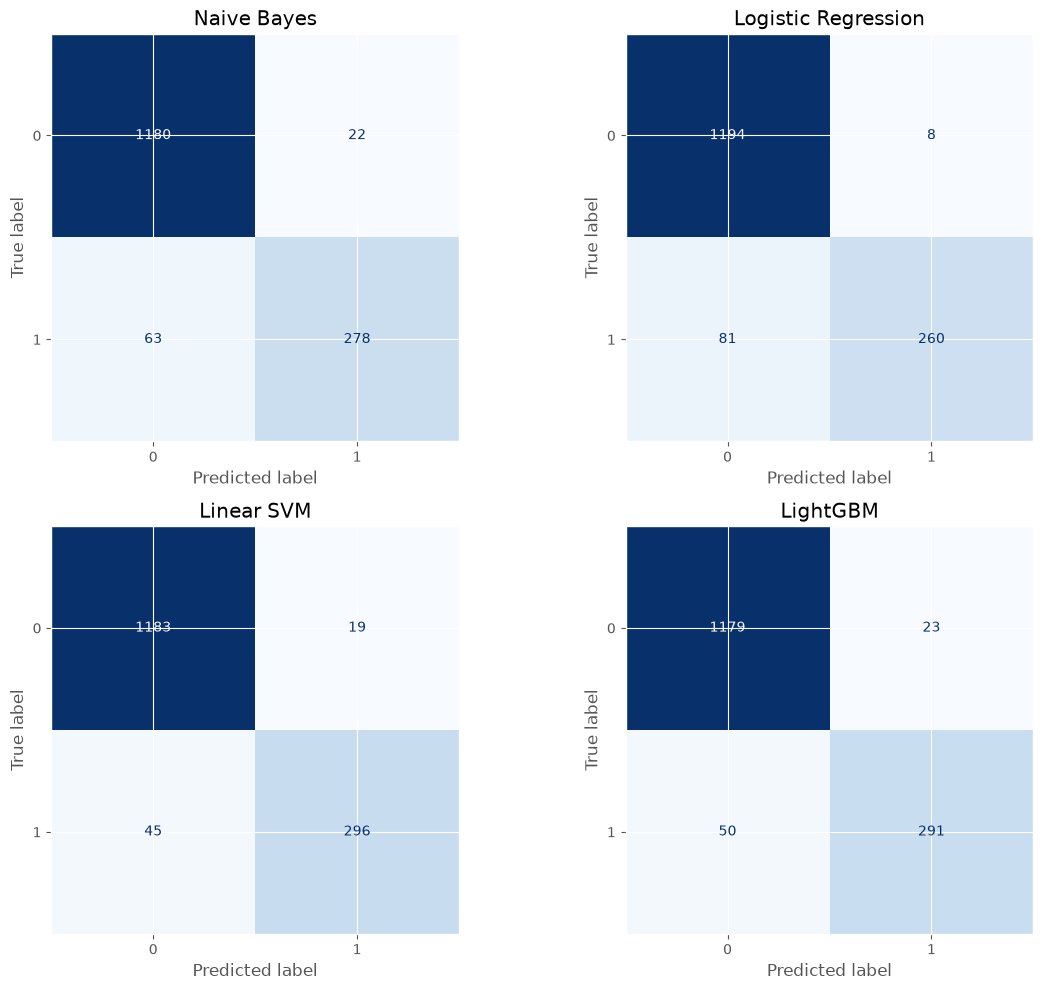

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        model.predict(X_val_tfidf),
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

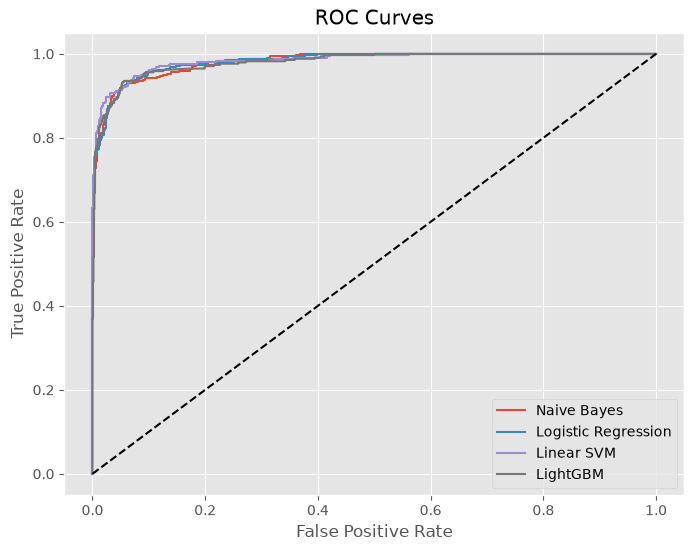

In [75]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    prob = model.predict_proba(X_val_tfidf)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.show()

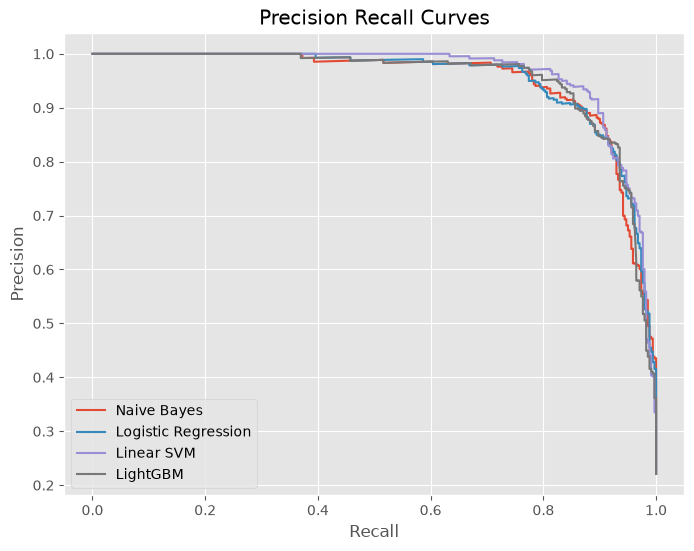

In [76]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    prob = model.predict_proba(X_val_tfidf)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_val,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curves")

plt.legend()

plt.show()

In [77]:
param_grid = {
    "estimator__C": [
        0.01,
        0.1,
        1,
        2,
        5,
        10
    ]
}

In [78]:
from sklearn.model_selection import (
    GridSearchCV
)

In [79]:
base_svm = CalibratedClassifierCV(
    LinearSVC(
        random_state=SEED
    )
)

grid_search = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train_tfidf,
    y_train
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CalibratedCla...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection str

In [80]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'estimator__C': 1}
0.8882857394367514


In [81]:
best_model = grid_search.best_estimator_

val_pred = best_model.predict(X_val_tfidf)

print(classification_report(
    y_val,
    val_pred
))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1202
           1       0.94      0.87      0.90       341

    accuracy                           0.96      1543
   macro avg       0.95      0.93      0.94      1543
weighted avg       0.96      0.96      0.96      1543



In [82]:
X_train_final = pd.concat([
    X_train,
    X_val
])

y_train_final = pd.concat([
    y_train,
    y_val
])

In [83]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    sublinear_tf=True,
    lowercase=False
)

X_train_final = tfidf_vectorizer.fit_transform(
    X_train_final
)

X_test_final = tfidf_vectorizer.transform(
    X_test
)

In [84]:
best_model.fit(
    X_train_final,
    y_train_final
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=1...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00283119332F0>, 

In [85]:
print(X_train_final.shape)
print(X_test_final.shape)

(8743, 10000)
(1543, 10000)


In [86]:
test_pred = best_model.predict(
    X_test_final
)

test_prob = best_model.predict_proba(
    X_test_final
)[:,1]

print(classification_report(
    y_test,
    test_pred
))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1202
           1       0.92      0.87      0.89       341

    accuracy                           0.95      1543
   macro avg       0.94      0.92      0.93      1543
weighted avg       0.95      0.95      0.95      1543



In [87]:
metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1 Score": f1_score(y_test, test_pred),
    "ROC AUC": roc_auc_score(y_test, test_prob),
    "PR AUC": average_precision_score(y_test, test_prob)
}

pd.DataFrame(
    metrics,
    index=["Linear SVM"]
).T

,Linear SVM
Accuracy,0.953338
Precision,0.916409
Recall,0.868035
F1 Score,0.891566
ROC AUC,0.984115
PR AUC,0.947953


In [88]:
feature_names = tfidf_vectorizer.get_feature_names_out()

coefs = np.vstack([
    clf.estimator.coef_[0]
    for clf in best_model.calibrated_classifiers_
])

coef = coefs.mean(axis=0)

importance = pd.DataFrame({
    "feature": feature_names,
    "weight": coef
})

importance.head()

,feature,weight
0,aa,-0.073112
1,ab,0.250734
2,abacustech,-0.268272
3,abacustech net,-0.268272
4,abdominal,0.367129


In [89]:
spam_words = (
    importance
    .sort_values("weight", ascending=False)
    .head(30)
)

spam_words

,feature,weight
4399,http,2.632537
5899,mobile,2.047830
1441,claim,1.940228
6550,paliourg,1.877299
9844,woman,1.771610
5273,loading,1.763032
4570,info,1.702671
9357,uk,1.634793
7153,prize,1.626230
9553,video,1.580079


In [90]:
ham_words = (
    importance
    .sort_values("weight")
    .head(30)
)

ham_words

,feature,weight
2978,enron,-2.262970
2990,enron com,-1.215041
3750,gas,-1.009301
2104,daren,-0.995577
5206,liked,-0.992974
4021,gt,-0.984336
2911,employee,-0.979627
6840,plan,-0.968659
8974,thanks,-0.954485
5374,lt gt,-0.924525


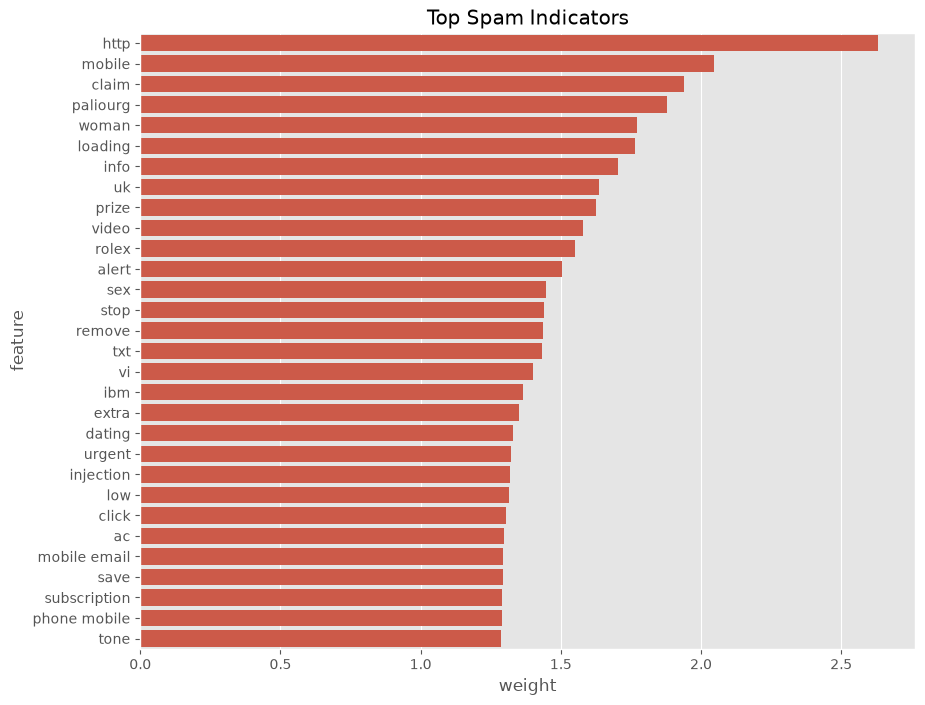

In [91]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=spam_words,
    x="weight",
    y="feature"
)

plt.title("Top Spam Indicators")

plt.show()

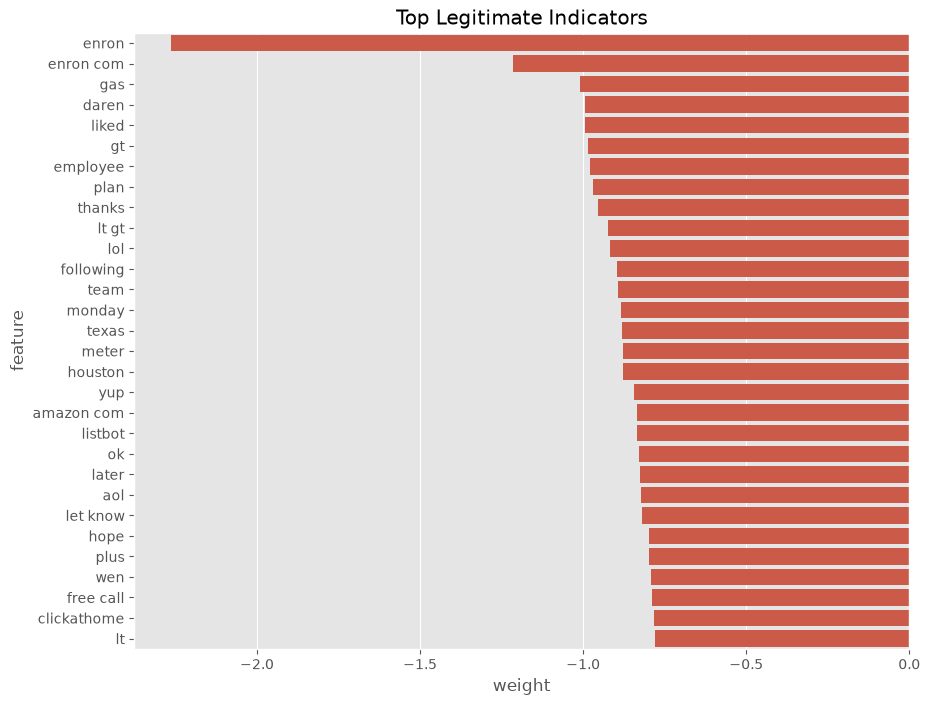

In [92]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=ham_words,
    x="weight",
    y="feature"
)

plt.title("Top Legitimate Indicators")

plt.show()

In [93]:
def predict_sms(message):

    processed = preprocess_text(message)

    vector = tfidf_vectorizer.transform([processed])

    prediction = best_model.predict(vector)[0]

    probability = best_model.predict_proba(vector)[0][prediction]

    label = "Scam" if prediction else "Legitimate"

    return label, probability

In [94]:

MODEL_DIR = Path("../../models/sms")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [95]:
joblib.dump(
    best_model,
    MODEL_DIR / "sms_model.pkl"
)

['..\\..\\models\\sms\\sms_model.pkl']

In [96]:
joblib.dump(
    tfidf_vectorizer,
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

['..\\..\\models\\sms\\tfidf_vectorizer.pkl']

In [97]:
with open(
    MODEL_DIR / "metrics.json",
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )